In [1]:
import sys
sys.path.append("/axovol/l1ad/src")  # project root
### Imports
import json
import numpy as np
from torch.utils import data
import yaml
import h5py
import torch
# import trainer
import model
import torch.nn.functional as F

2026-04-02 23:53:32.506124: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-02 23:53:32.561518: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-02 23:53:33.969214: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
def load_config(config_path, overrides=None):
    """Load YAML config and apply CLI overrides."""
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    if overrides:
        for key, value in overrides.items():
            keys = key.split(".")
            sub = config
            for k in keys[:-1]:
                sub = sub.setdefault(k, {})
            sub[keys[-1]] = value
    return config

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
device

device(type='cuda')

In [5]:
f = h5py.File('../training/v5/conditionsupdate_apr25.h5', 'r')

In [6]:
x_train = f['data']["Background_data"]["Train"]["DATA"][:100000]
x_test = f['data']["Background_data"]["Test"]["DATA"][:50000]
x_sig = f['data']["Signal_data"]["GluGluHToBB_M-125"]["DATA"][:50000]

scale = f['data']["Normalisation"]["norm_scale"][:]
bias = f['data']["Normalisation"]["norm_bias"][:]
x_train = torch.tensor(np.reshape(x_train,(x_train.shape[0],-1))).to(torch.float32).to(device)
x_test = torch.tensor(np.reshape(x_test,(x_test.shape[0],-1))).to(torch.float32).to(device)
x_sig = torch.tensor(np.reshape(x_sig,(x_sig.shape[0],-1))).to(torch.float32).to(device)


In [7]:
# # Load data
# x_train = f['data']["Background_data"]["Train"]["DATA"][:100000]
# x_test  = f['data']["Background_data"]["Test"]["DATA"][:50000]
# x_sig   = f['data']["Signal_data"]["GluGluHToBB_M-125"]["DATA"][:50000]

# # Convert to PyTorch tensors (float32, on device)
# x_train = torch.tensor(x_train, dtype=torch.float32, device=device)
# x_test  = torch.tensor(x_test, dtype=torch.float32, device=device)
# x_sig   = torch.tensor(x_sig, dtype=torch.float32, device=device)

# # Get number of constituents and features
# num_const, num_feat = x_train.shape[1], x_train.shape[2]

# # ----- Recalculate scale and bias -----
# percentiles = (5, 95)  # robust scaling percentiles
# target_range = (0, 1)  # normalized range

# scale = torch.ones((num_const, num_feat), device=device)
# bias  = torch.zeros((num_const, num_feat), device=device)

# for i in range(num_const):
#     for j in range(num_feat):
#         col = x_train[:, i, j]
#         mask = col != 0
#         col_masked = col[mask]

#         # Handle empty tensor
#         if col_masked.numel() == 0:
#             col_masked = col  # fallback to all entries

#         l0 = torch.quantile(col_masked, percentiles[0]/100)
#         h0 = torch.quantile(col_masked, percentiles[1]/100)
#         l1, h1 = target_range

#         scale[i, j] = (h0 - l0) / (h1 - l1)
#         bias[i, j]  = (l0 * h1 - h0 * l1) / (h1 - l1)

# # Avoid division by zero
# scale[scale == 0] = 1.0

# # ----- Apply normalization -----
# x_train_norm = (x_train - bias) / scale
# x_test_norm  = (x_test  - bias) / scale
# x_sig_norm   = (x_sig   - bias) / scale

# # Flatten for model input
# x_train_norm = x_train_norm.view(x_train_norm.shape[0], -1)
# x_test_norm  = x_test_norm.view(x_test_norm.shape[0], -1)
# x_sig_norm   = x_sig_norm.view(x_sig_norm.shape[0], -1)

In [9]:
batch_size = 2048

train_loader = data.DataLoader(
            dataset=data.TensorDataset(x_train),
            batch_size=batch_size,
        )

val_loader = data.DataLoader(
            dataset=data.TensorDataset(x_test),
            batch_size=batch_size,
        )

val_loader_no_batch = data.DataLoader(
    dataset=data.TensorDataset(x_test),
    batch_size=len(x_train),
)

sig_loader = data.DataLoader(
            dataset=data.TensorDataset(x_sig),
            batch_size=batch_size,
        )

In [10]:
# batch_size = 2048

# train_loader = data.DataLoader(
#             dataset=data.TensorDataset(x_train_norm),
#             batch_size=batch_size,
#         )

# val_loader = data.DataLoader(
#             dataset=data.TensorDataset(x_test_norm),
#             batch_size=batch_size,
#         )

# val_loader_no_batch = data.DataLoader(
#     dataset=data.TensorDataset(x_test_norm),
#     batch_size=len(x_train),
# )

# sig_loader = data.DataLoader(
#             dataset=data.TensorDataset(x_sig_norm),
#             batch_size=batch_size,
#         )

In [11]:
class MyLoader():
    def __init__(self, train_loader, val_loader, val_loader_no_batch, ood_loader) -> None:
        self.training_loader = train_loader
        self.validation_loader = val_loader
        self.validation_loader_no_batch = val_loader_no_batch
        self.ood_loader = ood_loader
        
loaders = MyLoader(train_loader, val_loader, val_loader_no_batch, sig_loader)

In [12]:
config = yaml.safe_load(open("config/config.yaml", "r"))
config['training']["batch_size"] = batch_size
config['training']['n_epochs'] = 5

In [13]:
config

{'data': {'filepath': '../training/v5/conditionsupdate_apr25.h5',
  'output': 'output_full_10_21',
  'standardize': False,
  'min_max': True,
  'n_train_sample': 50000,
  'n_test_sample': 10000},
 'training': {'batch_size': 2048,
  'es_patience': 5000,
  'n_epochs': 5,
  'optimizer': 'AdamW',
  'learning_rate': 0.005,
  'lr_scheduler': 'ReduceLROnPlateau',
  'lr_scheduler_args': {'mode': 'min',
   'factor': 0.8,
   'patience': 20,
   'threshold': 0.001,
   'cooldown': 10,
   'threshold_mode': 'rel',
   'min_lr': 0}},
 'wnae': {'sampling': 'pcd',
  'x_step': 5,
  'x_step_size': 0.05,
  'x_noise_std': 0.22,
  'x_temperature': 0.063,
  'x_bound': [-3, 3],
  'x_clip_grad': None,
  'x_reject_boundary': False,
  'x_mh': False,
  'z_step': 5,
  'z_step_size': 0.05,
  'z_temperature': 0.063,
  'z_noise_std': 1,
  'z_bound': None,
  'z_clip_grad': None,
  'z_reject_boundary': False,
  'z_mh': False,
  'spherical': False,
  'initial_dist': 'gaussian',
  'replay': True,
  'replay_ratio': 0.95,
  

In [14]:
encoder = model.Encoder(
    input_size=57,
    intermediate_architecture=[29],
    bottleneck_size=10,
    drop_out=None
).to(device)

In [15]:
vicreg = model.VICReg(
    encoder=encoder,
    # sim_coeff=25.0,
    # std_coeff=25.0,
    # cov_coeff=1.0
).to(device)

In [16]:
vicreg

VICReg(
  (encoder): Encoder(
    (layers): ModuleList(
      (0): Linear(in_features=57, out_features=29, bias=True)
      (1): Linear(in_features=29, out_features=10, bias=True)
    )
    (dropout_layers): ModuleList()
  )
  (projector): VICRegProjector(
    (model): Sequential(
      (0): Linear(in_features=10, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=128, out_features=128, bias=True)
      (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
)

In [17]:
import model.augmentations as aug

In [19]:
blur_p = 0.9004016520359364
blur_m = 0.92685112547458
blur_s = 0.749655944679925
mask_p = 0.5709886168264394


In [20]:
f['data'].keys()

<KeysViewHDF5 ['Background_data', 'Normalisation', 'Signal_data']>

In [21]:
scale = f['data']['Normalisation']['norm_scale']
bias = f['data']['Normalisation']['norm_bias']

In [22]:
### Augmentation
blur = aug.FastFeatureBlur(prob = blur_p, magnitude = blur_m, strength = blur_s).to(device)
blur_prime = aug.FastFeatureBlur(prob = blur_p, magnitude = blur_m, strength = blur_s).to(device)
mask = aug.FastObjectMask(prob=mask_p).to(device)
mask_prime = aug.FastObjectMask(prob=mask_p).to(device)
rotation = aug.FastLorentzRotation(prob = 0.5,
        norm_scale= scale,
        norm_bias=bias,
        # phi_indices: Optional[list] = None,
        ).to(device)
rotation_prime = aug.FastLorentzRotation(prob = 0.5,
        norm_scale= scale,
        norm_bias=bias,
        # phi_indices: Optional[list] = None,
        ).to(device)


In [31]:
def augment(x):

    x1 = blur(x.clone())
    x1 = mask(x1)
    x1 = rotation(x1)

    x2 = blur_prime(x.clone())
    x2 = mask_prime(x2)
    x2 = rotation_prime(x2)

    return x1,x2

In [32]:
for batch in loaders.training_loader:
    x = batch

In [33]:
optimizer = torch.optim.Adam(
    vicreg.parameters(),
    lr=5e-5,
    weight_decay=1e-6
)

In [34]:
def off_diagonal(x):
    n, m = x.shape
    assert n == m

    return x.flatten()[:-1].view(n-1, n+1)[:,1:].flatten()

In [35]:
def vicreg_loss(z1, z2,
                batch_size,
                num_features,
                sim_coeff=50,
                std_coeff=50,
                cov_coeff=1):

    repr_loss = F.mse_loss(z1, z2)

    z1 = z1 - z1.mean(dim=0, keepdim=True)
    z2 = z2 - z2.mean(dim=0, keepdim=True)

    std_z1 = torch.sqrt(z1.var(dim=0, unbiased=False) + 1e-4)
    std_z2 = torch.sqrt(z2.var(dim=0, unbiased=False) + 1e-4)

    std_loss = (
        torch.mean(torch.relu(1 - std_z1)) +
        torch.mean(torch.relu(1 - std_z2))
    ) / 2

    def covariance_loss(z):
        z = z - z.mean(dim=0)
        cov = (z.T @ z) / (z.shape[0] - 1)
        cov.fill_diagonal_(0)
        return (cov ** 2).sum() / z.shape[1]

    cov_loss = covariance_loss(z1) + covariance_loss(z2)

    loss = (
        sim_coeff * repr_loss +
        std_coeff * std_loss +
        cov_coeff * cov_loss
    )

    return repr_loss, std_loss, cov_loss, loss

In [42]:
for epoch in range(35):

    vicreg.train()

    # Running totals
    repr_total = 0
    std_total = 0
    cov_total = 0
    loss_total = 0

    batch_count = 0
    embedding_stds = []

    for batch in loaders.training_loader:

        batch = batch[0].to(device)

        # -------------------------
        # Generate two augmented views
        # -------------------------

        x1, x2 = augment(batch)

        # -------------------------
        # Forward pass
        # -------------------------

        z1 = vicreg(x1)
        z2 = vicreg(x2)

        repr_loss, std_loss, cov_loss, total_loss = vicreg_loss(
            z1,
            z2,
            batch_size=batch.shape[0],
            num_features=z1.shape[1]
        )

        # -------------------------
        # Backprop
        # -------------------------

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # -------------------------
        # Track losses
        # -------------------------

        repr_total += repr_loss.item()
        std_total += std_loss.item()
        cov_total += cov_loss.item()
        loss_total += total_loss.item()

        batch_count += 1

        # -------------------------
        # Track embedding std
        # (collapse detector)
        # -------------------------

        with torch.no_grad():
            latent = vicreg.encoder(x1)  # get pre-projector latent
            std_latent = latent.std(dim=0).mean().item()
            embedding_stds.append(std_latent)

    # -------------------------
    # Epoch averages
    # -------------------------

    avg_repr = repr_total / batch_count
    avg_std = std_total / batch_count
    avg_cov = cov_total / batch_count
    avg_loss = loss_total / batch_count

    avg_embed_std = np.mean(embedding_stds)

    # -------------------------
    # Print progress
    # -------------------------

    print(
        f"Epoch [{epoch+1}/200] | "
        f"Total: {avg_loss:.4f} | "
        f"Repr: {avg_repr:.4f} | "
        f"Std: {avg_std:.4f} | "
        f"Cov: {avg_cov:.4f} | "
        f"EmbedStd: {avg_embed_std:.4f}"
    )

Epoch [1/200] | Total: 44.5329 | Repr: 0.3205 | Std: 0.5294 | Cov: 2.0371 | EmbedStd: 0.1449
Epoch [2/200] | Total: 44.4465 | Repr: 0.3182 | Std: 0.5313 | Cov: 1.9762 | EmbedStd: 0.1500
Epoch [3/200] | Total: 43.7556 | Repr: 0.3024 | Std: 0.5331 | Cov: 1.9799 | EmbedStd: 0.1535
Epoch [4/200] | Total: 44.2067 | Repr: 0.3105 | Std: 0.5349 | Cov: 1.9401 | EmbedStd: 0.1528
Epoch [5/200] | Total: 44.2795 | Repr: 0.3101 | Std: 0.5367 | Cov: 1.9387 | EmbedStd: 0.1433
Epoch [6/200] | Total: 44.1813 | Repr: 0.3075 | Std: 0.5386 | Cov: 1.8775 | EmbedStd: 0.1398
Epoch [7/200] | Total: 44.1454 | Repr: 0.3051 | Std: 0.5404 | Cov: 1.8683 | EmbedStd: 0.1485
Epoch [8/200] | Total: 44.1893 | Repr: 0.3048 | Std: 0.5423 | Cov: 1.8338 | EmbedStd: 0.1435
Epoch [9/200] | Total: 44.3302 | Repr: 0.3064 | Std: 0.5442 | Cov: 1.8026 | EmbedStd: 0.1328
Epoch [10/200] | Total: 44.0066 | Repr: 0.2973 | Std: 0.5460 | Cov: 1.8427 | EmbedStd: 0.1479
Epoch [11/200] | Total: 43.5490 | Repr: 0.2862 | Std: 0.5479 | Cov: 1

In [37]:
std_per_dim = z1.std(dim=0)

print(std_per_dim.mean())

tensor(0.8215, device='cuda:0', grad_fn=<MeanBackward0>)


In [38]:
cov = torch.cov(z1.T)
off_diag = cov - torch.diag(torch.diag(cov))

print(off_diag.abs().mean())

tensor(0.1010, device='cuda:0', grad_fn=<MeanBackward0>)


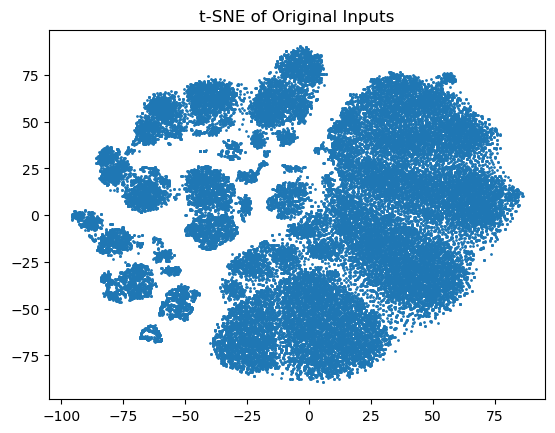

In [39]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch

originals = []

with torch.no_grad():
    for batch in loaders.validation_loader:
        x = batch[0].to(device)

        # Flatten if needed (important!)
        x_flat = x.view(x.size(0), -1)

        originals.append(x_flat.cpu().numpy())

originals = np.concatenate(originals)

tsne = TSNE(n_components=2)
proj_orig = tsne.fit_transform(originals)

plt.scatter(proj_orig[:,0], proj_orig[:,1], s=1)
plt.title("t-SNE of Original Inputs")
plt.show()

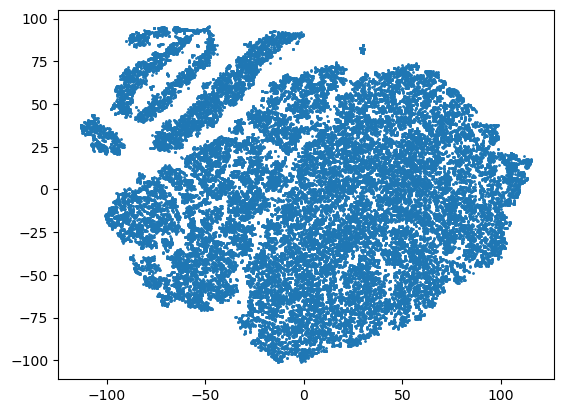

In [43]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

embeddings = []

with torch.no_grad():
    for batch in loaders.validation_loader:
        x = batch[0].to(device)
        z = vicreg.encoder(x)
        embeddings.append(z.cpu().numpy())

embeddings = np.concatenate(embeddings)

tsne = TSNE(n_components=2)
proj = tsne.fit_transform(embeddings)

plt.scatter(proj[:,0], proj[:,1], s=1)
plt.show()

In [29]:
# Pick one batch from your loader
batch = next(iter(loaders.training_loader))[0].to(device)

# Apply augmentation
x1, x2 = augment(batch)

# Compute difference between the two views
diff = (x1 - x2).abs().mean().item()
print("Average difference between augmented views:", diff)

Average difference between augmented views: 0.6516128182411194


In [30]:
x1, x2 = augment(batch)
diff_per_feature = (x1 - x2).abs().mean(dim=0)
print("Diff per feature:", diff_per_feature)

Diff per feature: tensor([0.6108, 0.3292, 0.7375, 0.7287, 0.7160, 0.7427, 0.7503, 0.7434, 0.7342,
        0.7629, 0.7367, 0.7437, 0.7388, 0.7478, 0.7379, 0.7399, 0.7393, 0.7359,
        0.7698, 0.7399, 0.7644, 1.3752, 0.3397, 0.7005, 1.3437, 0.3291, 0.7083,
        0.5618, 0.4478, 0.5078, 0.8748, 0.4078, 0.5479, 0.8474, 0.3771, 0.6223,
        0.8415, 0.3537, 0.6627, 0.7543, 0.3315, 0.6879, 0.7630, 0.3351, 0.6937,
        0.7600, 0.3395, 0.7100, 0.6931, 0.3171, 0.6958, 0.6838, 0.3275, 0.7147,
        1.0588, 0.3277, 0.7002], device='cuda:0')


In [27]:
batch[0]

tensor([ 0.3750,  0.0000, -0.8438,  1.1250, -0.1875,  0.3438, -1.0000,  0.8125,
         0.6875, -1.5000,  1.0312,  0.7969, -1.0000, -0.2188, -0.7969, -1.5000,
         0.0000, -1.1172, -3.0000,  0.0156, -1.1133, -3.0000,  0.0156, -1.1016,
        -3.0000,  0.0156, -1.1172,  0.1250, -0.1094,  0.3594,  0.3750, -0.8125,
         1.0469, -2.1875,  0.0000, -1.1250, -1.7500,  0.0000, -1.1250, -1.3750,
         0.0000, -1.1250, -1.3125,  0.0000, -1.1250, -1.2500,  0.0000, -1.1406,
        -1.1250,  0.0000, -1.1406, -1.1250,  0.0000, -1.1250, -2.1250,  0.0312,
        -1.1250], device='cuda:0')

In [28]:
x1, x2 = augment(batch)

In [29]:
x1[0]

tensor([ 0.0000e+00,  0.0000e+00,  5.5170e+01,  5.5170e+01,  5.5170e+01,
         5.5170e+01,  5.4170e+01,  2.2068e+02,  2.2085e+02,  2.2068e+02,
         2.2171e+02,  5.5966e+01,  5.5170e+01,  5.5401e+01,  5.4373e+01,
         5.5170e+01,  5.5170e+01,  5.5170e+01,  5.5170e+01,  5.5185e+01,
         5.5170e+01,  0.0000e+00,  7.3768e-01, -1.1016e+00,  0.0000e+00,
         0.0000e+00, -0.0000e+00,  0.0000e+00,  0.0000e+00,  7.4776e-01,
         0.0000e+00,  0.0000e+00,  5.4117e-01,  5.7840e-02,  4.2326e-01,
         0.0000e+00, -0.0000e+00,  0.0000e+00,  2.2767e-01, -1.3750e+00,
         0.0000e+00, -0.0000e+00, -0.0000e+00,  1.3302e-01,  2.7877e-01,
         1.8263e-01,  0.0000e+00, -0.0000e+00,  7.0001e-01,  0.0000e+00,
         0.0000e+00,  4.7937e-01,  7.3502e-01,  0.0000e+00,  0.0000e+00,
         7.9379e-02,  4.4174e-03], device='cuda:0')

In [30]:
x2[0]

tensor([ 3.8313e-02,  2.1194e-01, -1.8136e+01, -1.8163e+01, -1.8135e+01,
        -1.8146e+01, -1.8163e+01, -1.8786e+01, -1.8787e+01, -1.8784e+01,
        -1.8782e+01, -1.8136e+01, -1.8215e+01, -1.8156e+01, -1.8150e+01,
        -1.8136e+01, -1.8171e+01, -1.8158e+01, -1.8302e+01, -1.8137e+01,
        -1.8134e+01,  5.3545e-01,  2.7912e-01,  4.7605e-01,  5.4142e-01,
         6.7966e-01, -1.1172e+00,  1.2500e-01,  6.2722e-01,  2.6446e-01,
         1.9490e-01,  8.4780e-01,  6.2707e-01, -2.1875e+00,  4.4826e-01,
         3.4949e-01,  5.9616e-03,  6.8176e-03,  6.0501e-01, -4.8611e-02,
         2.0990e-02,  3.8233e-01,  7.6142e-01,  1.1835e-01, -1.1250e+00,
         6.6296e-02,  0.0000e+00,  4.1264e-01,  6.7964e-01,  0.0000e+00,
         6.6439e-01,  6.7078e-02,  7.3116e-02,  6.7453e-01, -1.2690e-01,
         6.2866e-01, -1.1250e+00], device='cuda:0')

In [24]:
def augment(x):

    x1 = blur(x.clone())
    x1 = mask(x1)
    x1 = rotation(x1)

    x2 = blur_prime(x.clone())
    x2 = mask_prime(x2)
    x2 = rotation_prime(x2)

    return x1,x2

In [25]:
x1 = blur(x.clone())
    x1 = mask(x1)
    x1 = rotation(x1)

IndentationError: unexpected indent (1752843571.py, line 2)

In [26]:
x = batch.clone()

NameError: name 'batch' is not defined

In [27]:
x1 = blur(x)
x1_mask = mask(x1)
x1_rot = rotation(x1_mask)

NameError: name 'x' is not defined

In [44]:
x[0]

tensor([ 0.3750,  0.0000, -0.8438,  1.1250, -0.1875,  0.3438, -1.0000,  0.8125,
         0.6875, -1.5000,  1.0312,  0.7969, -1.0000, -0.2188, -0.7969, -1.5000,
         0.0000, -1.1172, -3.0000,  0.0156, -1.1133, -3.0000,  0.0156, -1.1016,
        -3.0000,  0.0156, -1.1172,  0.1250, -0.1094,  0.3594,  0.3750, -0.8125,
         1.0469, -2.1875,  0.0000, -1.1250, -1.7500,  0.0000, -1.1250, -1.3750,
         0.0000, -1.1250, -1.3125,  0.0000, -1.1250, -1.2500,  0.0000, -1.1406,
        -1.1250,  0.0000, -1.1406, -1.1250,  0.0000, -1.1250, -2.1250,  0.0312,
        -1.1250], device='cuda:0')

In [45]:
x1[0]

tensor([ 0.9313,  0.0000,  0.0971,  0.6545,  0.1162,  0.3438,  0.6837,  0.2057,
         0.5311, -1.5000,  0.9761,  0.6859,  0.0991,  0.4221,  0.8433,  0.0363,
         0.0000, -1.1172,  0.5711,  0.0180, -1.1133,  0.3843,  0.4519, -0.0373,
        -3.0000,  0.2821,  0.2738,  0.1662,  0.1178,  0.7258,  0.8543,  0.7670,
         0.4394,  0.0322,  0.6036,  0.2455, -0.0726,  0.0000, -1.1250, -0.0102,
         0.6674, -0.0662,  0.7051,  0.0000, -0.0047,  0.4785,  0.2703, -1.1406,
         0.6711,  0.6897,  0.1176,  0.6169,  0.8862,  0.4067,  0.6117,  0.3741,
        -0.0785], device='cuda:0')

In [46]:
x1_mask[0]

tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.5311, -0.0000,  0.0000,  0.6859,  0.0991,  0.4221,  0.8433,  0.0363,
         0.0000, -0.0000,  0.0000,  0.0000, -0.0000,  0.0000,  0.4519, -0.0000,
        -0.0000,  0.0000,  0.0000,  0.0000,  0.1178,  0.0000,  0.0000,  0.0000,
         0.4394,  0.0322,  0.0000,  0.0000, -0.0000,  0.0000, -1.1250, -0.0102,
         0.0000, -0.0000,  0.7051,  0.0000, -0.0000,  0.0000,  0.0000, -1.1406,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.4067,  0.0000,  0.3741,
        -0.0000], device='cuda:0')

In [47]:
x1_rot[0]

tensor([ 0.0000e+00,  0.0000e+00,  1.0849e+02,  1.0849e+02,  1.0849e+02,
         1.0849e+02,  1.0849e+02,  4.3395e+02,  4.3448e+02,  4.3395e+02,
         4.3395e+02,  1.0917e+02,  1.0859e+02,  1.0891e+02,  1.0933e+02,
         1.0852e+02,  1.0849e+02,  1.0849e+02,  1.0849e+02,  1.0849e+02,
         1.0849e+02,  0.0000e+00,  4.5193e-01, -0.0000e+00, -0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  1.1781e-01,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  4.3937e-01,  3.2250e-02,  0.0000e+00,
         0.0000e+00, -0.0000e+00,  0.0000e+00, -1.1250e+00, -1.0152e-02,
         0.0000e+00, -0.0000e+00,  7.0513e-01,  0.0000e+00, -0.0000e+00,
         0.0000e+00,  0.0000e+00, -1.1406e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  4.0673e-01,  0.0000e+00,
         3.7410e-01, -0.0000e+00], device='cuda:0')